In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pandas_datareader import data as pdr
import plotly.offline as pyo

In [ ]:
# init
pyo.init_notebook_mode(connected=True)
pd.options.plotting.backend = 'plotly'

In [ ]:
pip install yfinance

In [ ]:
pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
# get data
import datetime as dt
from pandas_datareader import data as pdr
end = dt.datetime.now()
start = dt.datetime(2015,1,1)
df = pdr.get_data_yahoo(['^AXJO','CBA.AX','NAB.AX','STO.AX','BHP.AX'], start, end)

/usr/local/lib/python3.12/dist-packages/pandas_datareader/base.py:272: SymbolWarning:

Failed to read symbol: '^AXJO', replacing with NaN.

/usr/local/lib/python3.12/dist-packages/pandas_datareader/base.py:272: SymbolWarning:

Failed to read symbol: 'CBA.AX', replacing with NaN.

/usr/local/lib/python3.12/dist-packages/pandas_datareader/base.py:272: SymbolWarning:

Failed to read symbol: 'NAB.AX', replacing with NaN.

/usr/local/lib/python3.12/dist-packages/pandas_datareader/base.py:272: SymbolWarning:

Failed to read symbol: 'STO.AX', replacing with NaN.

/usr/local/lib/python3.12/dist-packages/pandas_datareader/base.py:272: SymbolWarning:

Failed to read symbol: 'BHP.AX', replacing with NaN.



RemoteDataError: No data fetched using 'YahooDailyReader'

In [ ]:
# sample view
print(df['Close'].head())

NameError: name 'df' is not defined

In [ ]:
# compute log returns
log_returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()

NameError: name 'df' is not defined

In [ ]:
# calculate daily std
daily_std = log_returns.std()

In [ ]:
# annualized volatility
annualized_vol = daily_std * np.sqrt(252)
print(annualized_vol * 100)

Ticker
BHP.AX    28.524814
CBA.AX    21.558228
NAB.AX    22.364906
STO.AX    40.356191
^AXJO     15.233594
dtype: float64


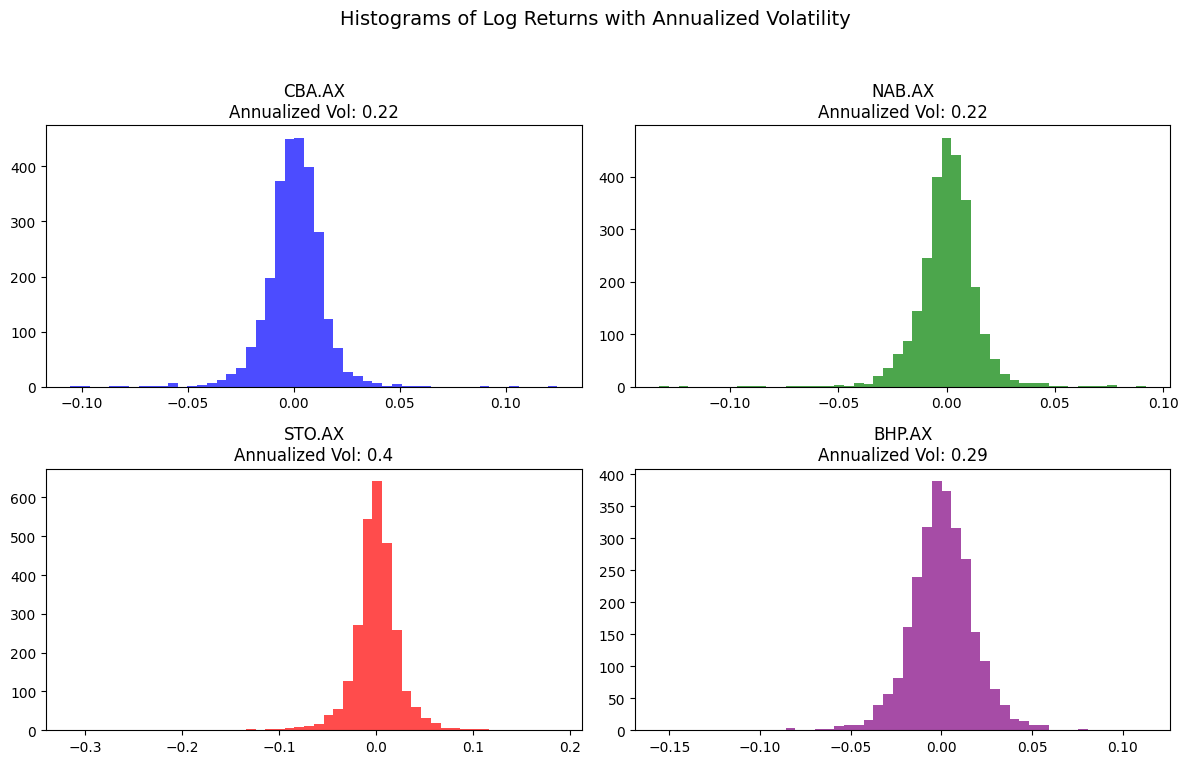

In [ ]:
# plot histogram of log returns with annualized volatility
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].hist(log_returns['CBA.AX'], bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title(f"CBA.AX\nAnnualized Vol: {round(annualized_vol['CBA.AX'], 2)}")


axes[0, 1].hist(log_returns['NAB.AX'], bins=50, alpha=0.7, color='green')
axes[0, 1].set_title(f"NAB.AX\nAnnualized Vol: {round(annualized_vol['NAB.AX'], 2)}")


axes[1, 0].hist(log_returns['STO.AX'], bins=50, alpha=0.7, color='red')
axes[1, 0].set_title(f"STO.AX\nAnnualized Vol: {round(annualized_vol['STO.AX'], 2)}")


axes[1, 1].hist(log_returns['BHP.AX'], bins=50, alpha=0.7, color='purple')
axes[1, 1].set_title(f"BHP.AX\nAnnualized Vol: {round(annualized_vol['BHP.AX'], 2)}")


fig.suptitle("Histograms of Log Returns with Annualized Volatility", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
